# DL Project Work 1 (Group 17474)

# Rhushabh Vaghela
## India
## rhushabhvaghela@gmail.com

# Anubhav Sharma
## India
## anubhav.sharma1604@gmail.com

# Justice Kwame Appati
## Ghana
## jkappati@ug.edu.gh


In [ ]:
!pip install yfinance --upgrade
!pip install pyts

In [ ]:
# Setup
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from statsmodels.tsa.stattools import adfuller

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from pyts.image import GramianAngularField

# Universal Determinism (for getting same results after re-run)
random.seed(1234)
np.random.seed(1234)
tf.random.set_seed(1234)
tf.keras.utils.set_random_seed(1234)

# Campbell & Thompson Out-of-Sample R2 Metric
def R2_campbell(y_true, y_pred, y_train_mean):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    sse = np.sum((y_true - y_pred) ** 2)
    tse = np.sum((y_true - y_train_mean) ** 2)
    return 1.0 - (sse / tse)

## Step 1: Data Gathering, Preprocessing, and EDA

[*********************100%***********************]  5 of 5 completed


--- Augmented Dickey-Fuller (ADF) Test Results ---
DBO - ADF Stat: -31.4478, p-value: 0.0000e+00 (Stationary: True)
GLD - ADF Stat: -63.8459, p-value: 0.0000e+00 (Stationary: True)
SHY - ADF Stat: -9.6546, p-value: 1.4047e-16 (Stationary: True)
SPY - ADF Stat: -15.7645, p-value: 1.1810e-28 (Stationary: True)
TLT - ADF Stat: -12.1254, p-value: 1.7855e-22 (Stationary: True)

--- Daily Return Summary Statistics (%) ---
         count      mean       std        min       25%       50%       75%  \
Ticker                                                                        
DBO     4025.0  0.010792  2.011037 -16.645320 -1.006104  0.109458  1.115907   
GLD     4025.0  0.031977  1.115100  -8.780826 -0.513829  0.049961  0.595342   
SHY     4025.0  0.005733  0.088245  -0.656609 -0.035352  0.000000  0.037492   
SPY     4025.0  0.040982  1.290331 -10.942361 -0.415744  0.065403  0.597836   
TLT     4025.0  0.018965  0.958291  -6.668318 -0.548767  0.047444  0.574174   

              max  
Ticker

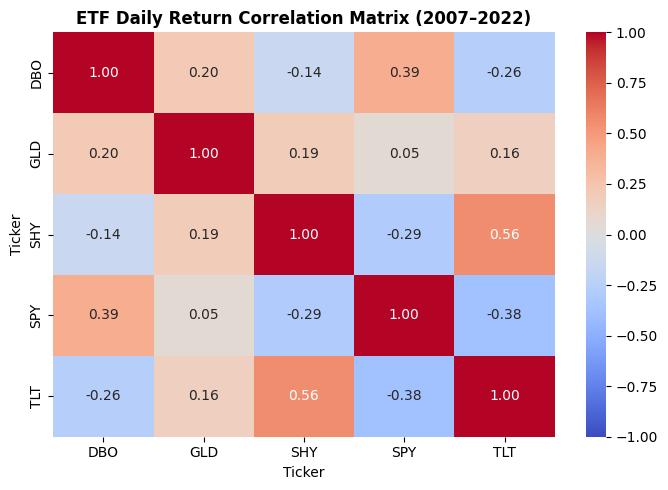

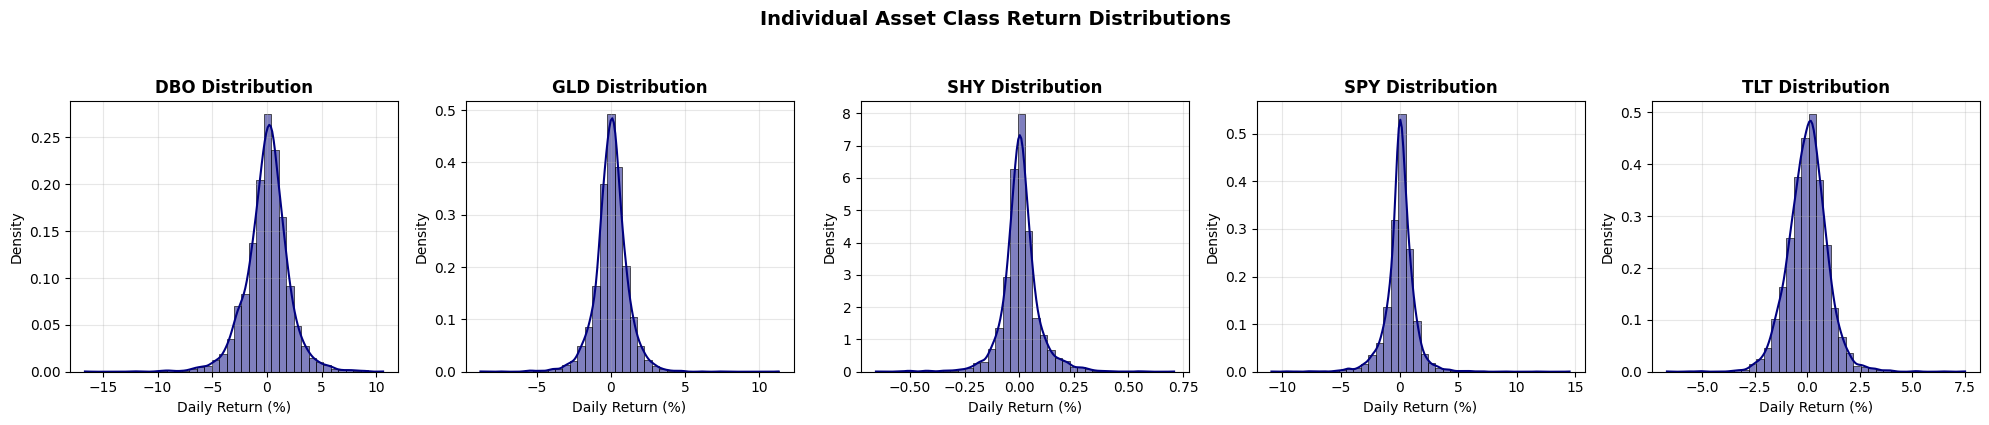

In [ ]:
tickers = ['SPY', 'TLT', 'SHY', 'GLD', 'DBO']
raw_prices = yf.download(tickers, start='2007-01-01', end='2022-12-31')['Close'].dropna()

# Daily Percentage Returns
ret_df = (raw_prices.pct_change() * 100.0).dropna()

# ADF Stationarity Test
print("--- Augmented Dickey-Fuller (ADF) Test Results ---")
for col in ret_df.columns:
    stat, pval, *_ = adfuller(ret_df[col])
    print(f"{col} - ADF Stat: {stat:.4f}, p-value: {pval:.4e} (Stationary: {pval < 0.05})")

# Summary Statistics
print("\n--- Daily Return Summary Statistics (%) ---")
print(ret_df.describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']])

# Joint Distribution: Correlation Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(ret_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('ETF Daily Return Correlation Matrix (2007–2022)', fontweight='bold')
plt.tight_layout()
plt.show()

# Individual Return Distributions (Histograms + KDE)
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=False)
for i, col in enumerate(ret_df.columns):
    sns.histplot(ret_df[col], kde=True, ax=axes[i], bins=40, color='navy', stat='density')
    axes[i].set_title(f'{col} Distribution', fontweight='bold')
    axes[i].set_xlabel('Daily Return (%)')
    axes[i].grid(alpha=0.3)
plt.suptitle('Individual Asset Class Return Distributions', y=1.05, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **Interpretation of Results:**

### **ADF Stationarity Test**
**Result:** All 5 ETFs have p-values well below the standard 5% (0.05) threshold ($p \approx 0.000$).

**Meaning:** All percentage return series are strictly stationary. This justifies feeding them directly into the neural network, as raw prices have unit roots (non-stationary trends) that lead to spurious learning.  

### **Summary Statistics (Risk & Return Profiles)**
**Volatilities:** Standard deviations clearly align with their asset classes:
- DBO (Crude Oil, 2.01%) and SPY (Equities, 1.29%) have the highest daily volatility.
- SHY (1–3 Year Treasury, 0.088%) is cash-like with minimal volatility.
- TLT (Long-Term Treasury, 0.96%) and GLD (Gold, 1.12%) sit in the middle.

**Skewness / Tails:** Every risky asset exhibits heavy tails and asymmetry (e.g., DBO has a minimum daily return of -16.65% and SPY of -10.94%).

### **Correlation Matrix Heatmap**

- **Flight-to-Safety:** SPY has negative correlations with Treasuries (-0.38 with TLT, -0.29 with SHY), confirming the classic diversification benefit between stocks and bonds.
- **Duration Spread:** TLT and SHY have a strong positive correlation (+0.56), as expected from fixed-income instruments.
- **Uncorrelated Anchors:** GLD shows almost zero correlation to equities (0.05 with SPY), serving as an effective non-correlated diversifier.
- **Growth Sensitivity:** DBO and SPY have a positive correlation (+0.39), showing that energy prices move with economic expansion.

## Step 2: Multi-Layer Perceptron (MLP) Models

In [ ]:
# Target Construction: 25-Day Forward Compounded Return
def get_forward_target(series, horizon=25):
    # Compounded forward return over next 25 trading days
    fwd_ret = series.rolling(horizon).apply(lambda x: 100.0 * (np.prod(1.0 + x / 100.0) - 1.0)).shift(-horizon)
    return fwd_ret

# Chronological Date Masks
val_start_date = "2016-01-01"
test_start_date = "2018-01-01"
test_end_date = "2022-12-30"

# MLP model
mlp_models, mlp_results = {}, {}
mlp_feature_cols = ['Ret25_i', 'Ret60_i', 'Ret90_i', 'Ret120_i', 'Ret240_i']

for ticker in tickers:
    df_m = pd.DataFrame({'Ret': ret_df[ticker]})
    for w in [25, 60, 90, 120, 240]:
        df_m[f'Ret{w}_i'] = df_m['Ret'].rolling(w).apply(lambda x: 100.0 * (np.prod(1.0 + x / 100.0) - 1.0))
    df_m['Target25'] = get_forward_target(df_m['Ret'], 25)
    df_m = df_m.dropna()

    train_m = df_m.index < val_start_date
    val_m = (df_m.index >= val_start_date) & (df_m.index < test_start_date)
    test_m = (df_m.index >= test_start_date) & (df_m.index <= test_end_date)

    scaler = MinMaxScaler(feature_range=(-1, 1))
    X_tr = scaler.fit_transform(df_m.loc[train_m, mlp_feature_cols].values)
    X_va = scaler.transform(df_m.loc[val_m, mlp_feature_cols].values)
    X_te = scaler.transform(df_m.loc[test_m, mlp_feature_cols].values)
    y_tr = df_m.loc[train_m, 'Target25'].values
    y_va = df_m.loc[val_m, 'Target25'].values
    y_te = df_m.loc[test_m, 'Target25'].values

    tf.keras.backend.clear_session()
    tf.random.set_seed(1234)

    model = Sequential([
        Input(shape=(5,)),
        Dense(25, activation='relu'),
        Dropout(0.2),
        Dense(15, activation='relu'),
        Dropout(0.2),
        Dense(10, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='mae')
    es = EarlyStopping(monitor='val_loss', mode='min', patience=20, restore_best_weights=True)
    model.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=200, batch_size=32, verbose=0, callbacks=[es], shuffle=False)

    y_pr_tr = model.predict(X_tr, verbose=0).flatten()
    y_pr_te = model.predict(X_te, verbose=0).flatten()

    mlp_models[ticker] = model
    mlp_results[ticker] = {
        "Train MAE": np.mean(np.abs(y_tr - y_pr_tr)),
        "Train R2": R2_campbell(y_tr, y_pr_tr, np.mean(y_tr)),
        "Test MAE": np.mean(np.abs(y_te - y_pr_te)),
        "Test R2_OOS": R2_campbell(y_te, y_pr_te, np.mean(y_tr))
    }

print("\n--- Step 2: MLP Performance Summary ---")
print(pd.DataFrame(mlp_results).T)


--- Step 2: MLP Performance Summary ---
     Train MAE  Train R2  Test MAE  Test R2_OOS
SPY   3.882590  0.020006  4.218815    -0.008145
TLT   3.465850  0.015796  3.650601     0.009392
SHY   0.261908 -0.108609  0.340960     0.042570
GLD   4.601165 -0.004321  3.214383    -0.021891
DBO   7.673553 -0.014095  8.430509     0.037654


## **Interpretation of Results:**

- **In-Sample Performance:** Most single-asset MLPs exhibit near-zero training fit (TLT: 0.0158, GLD: -0.0043, DBO: -0.0141, SHY: -0.1086), demonstrating that feedforward models using only isolated univariate return lags suffer from underfitting. SPY shows a modest in-sample fit of 0.0199.

- **Fixed Income Predictability:** SHY generalizes well out-of-sample with a positive Test $R^2$ of 0.0426 and the lowest nominal error by far (Test MAE: 0.34%), as MinMax scaling stabilizes convergence across its low-volatility interest rate regime. TLT also generalizes consistently with a positive Test $R^2$ of 0.0094 (Test MAE: 3.65%).

- **Equities & Gold Struggles:** SPY fails to generalize out-of-sample, turning from positive in-sample fit to a negative Test $R^2$ of -0.0082 (Test MAE: 4.22%). GLD remains negative out-of-sample (Test $R^2$: -0.0219, Test MAE: 3.21%), both performing worse than the historical mean baseline.

- **Commodities (DBO):** DBO delivers positive out-of-sample predictability (Test $R^2$: 0.0377), though its nominal error remains the highest (Test MAE: 8.43%) due to the inherent volatility and fat tails of crude oil.

## Step 3: CNN-GAF vs MLP

In [ ]:
W_SIZE = 30
cnn_models, cnn_results = {}, {}

for ticker in tickers:
    series = ret_df[ticker]
    fwd_tgt = get_forward_target(series, 25)

    # Aligning series and target, define chronological split masks
    valid_idx = series.index[W_SIZE : len(series) - 25]
    train_dates = series.index[series.index < val_start_date]

    # Fitting MinMaxScaler on the 1D training return series only
    scaler_1d = MinMaxScaler(feature_range=(-1, 1))
    scaler_1d.fit(series.loc[train_dates].values.reshape(-1, 1))
    scaled_series = pd.Series(
        scaler_1d.transform(series.values.reshape(-1, 1)).flatten(),
        index=series.index,
    )

    # Constructing 30-day sliding windows from the pre-scaled 1D series
    X_seq, y_seq, dates_seq = [], [], []
    for i in range(W_SIZE, len(series) - 25):
        X_seq.append(scaled_series.iloc[i - W_SIZE : i].values)
        y_seq.append(fwd_tgt.iloc[i - 1])
        dates_seq.append(series.index[i - 1])

    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)
    dates_seq = pd.to_datetime(dates_seq)

    train_m = dates_seq < val_start_date
    val_m = (dates_seq >= val_start_date) & (dates_seq < test_start_date)
    test_m = (dates_seq >= test_start_date) & (dates_seq <= test_end_date)

    # Transforming contiguous 30-day sequences into 30x30 GAF summation images
    gaf = GramianAngularField(image_size=30, method="summation")
    X_tr_gaf = np.expand_dims(gaf.fit_transform(X_seq[train_m]), -1)
    X_va_gaf = np.expand_dims(gaf.transform(X_seq[val_m]), -1)
    X_te_gaf = np.expand_dims(gaf.transform(X_seq[test_m]), -1)

    y_tr, y_va, y_te = y_seq[train_m], y_seq[val_m], y_seq[test_m]

    tf.keras.backend.clear_session()
    tf.random.set_seed(1234)

    # Hierarchical 2D Convolutional Topology
    model = Sequential(
        [
            Input(shape=(30, 30, 1)),
            Conv2D(16, (3, 3), activation="relu", padding="same"),
            MaxPooling2D((2, 2)),
            Conv2D(32, (3, 3), activation="relu", padding="same"),
            MaxPooling2D((2, 2)),
            Conv2D(64, (3, 3), activation="relu", padding="same"),
            MaxPooling2D((2, 2)),
            Flatten(),
            Dense(64, activation="relu"),
            Dropout(0.2),
            Dense(1),
        ]
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss="mae"
    )
    es = EarlyStopping(
        monitor="val_loss", mode="min", patience=20, restore_best_weights=True
    )
    model.fit(
        X_tr_gaf,
        y_tr,
        validation_data=(X_va_gaf, y_va),
        epochs=200,
        batch_size=32,
        verbose=0,
        callbacks=[es],
        shuffle=False,
    )

    y_pr_tr = model.predict(X_tr_gaf, verbose=0).flatten()
    y_pr_te = model.predict(X_te_gaf, verbose=0).flatten()

    cnn_models[ticker] = model
    cnn_results[ticker] = {
        "Train MAE": np.mean(np.abs(y_tr - y_pr_tr)),
        "Train R2": R2_campbell(y_tr, y_pr_tr, np.mean(y_tr)),
        "Test MAE": np.mean(np.abs(y_te - y_pr_te)),
        "Test R2_OOS": R2_campbell(y_te, y_pr_te, np.mean(y_tr)),
    }

print("\n--- Step 3: CNN-GAF Performance Summary ---")
print(pd.DataFrame(cnn_results).T)


--- Step 3: CNN-GAF Performance Summary ---
     Train MAE  Train R2  Test MAE  Test R2_OOS
SPY   3.926652 -0.022785  4.196967    -0.005381
TLT   3.409875 -0.011112  3.652344     0.023781
SHY   0.304356 -0.118572  0.347227     0.067561
GLD   4.501697  0.037284  3.245455    -0.032002
DBO   7.475552 -0.008751  8.376635     0.025426


## **Interpretation of Results:**

* **Out-of-Sample Performance:** Encoding 30-day contiguous return trajectories into 30x30 Gramian Angular Fields produces positive out-of-sample predictive fit for fixed income (SHY Test $R^2$: 0.0676, Test MAE: 0.35%; TLT Test $R^2$: 0.0238, Test MAE: 3.65%) and crude oil (DBO Test $R^2$: 0.0254, Test MAE: 8.38%). Equities (SPY Test $R^2$: -0.0054) and Gold (GLD Test $R^2$: -0.0320) remain slightly negative.

* **Architecture Comparison (CNN-GAF vs. MLP):** For sovereign debt (TLT and SHY), the CNN-GAF outperforms the feedforward MLP (TLT Test $R^2$: 0.0238 vs. MLP's 0.0094; SHY Test $R^2$: 0.0676 vs. MLP's 0.0426). Mapping temporal patterns into a 2D angular representation provides higher predictive fit for fixed income series than isolated multi-horizon features. For SPY, the CNN achieves a Test $R^2$ of -0.0054, slightly improving on the MLP (-0.0081).

## Step 4: Recurrent Neural Network

In [ ]:
lstm_models, lstm_results = {}, {}

for ticker in tickers:
    series = ret_df[ticker]
    fwd_tgt = get_forward_target(series, 25)

    train_dates = series.index[series.index < val_start_date]

    # Fitting 1D scaler strictly on training return observations
    scaler_1d = MinMaxScaler(feature_range=(-1, 1))
    scaler_1d.fit(series.loc[train_dates].values.reshape(-1, 1))
    scaled_series = pd.Series(
        scaler_1d.transform(series.values.reshape(-1, 1)).flatten(),
        index=series.index,
    )

    X_seq, y_seq, dates_seq = [], [], []
    for i in range(W_SIZE, len(series) - 25):
        X_seq.append(scaled_series.iloc[i - W_SIZE : i].values)
        y_seq.append(fwd_tgt.iloc[i - 1])
        dates_seq.append(series.index[i - 1])

    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)
    dates_seq = pd.to_datetime(dates_seq)

    train_m = dates_seq < val_start_date
    val_m = (dates_seq >= val_start_date) & (dates_seq < test_start_date)
    test_m = (dates_seq >= test_start_date) & (dates_seq <= test_end_date)

    X_tr_sc = np.expand_dims(X_seq[train_m], -1)
    X_va_sc = np.expand_dims(X_seq[val_m], -1)
    X_te_sc = np.expand_dims(X_seq[test_m], -1)
    y_tr, y_va, y_te = y_seq[train_m], y_seq[val_m], y_seq[test_m]

    tf.keras.backend.clear_session()
    tf.random.set_seed(1234)

    # Recurrent Gated Topology
    model = Sequential(
        [
            Input(shape=(30, 1)),
            LSTM(32, return_sequences=False, activation="tanh"),
            Dropout(0.2),
            Dense(16, activation="relu"),
            Dropout(0.2),
            Dense(1),
        ]
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss="mae"
    )
    es = EarlyStopping(
        monitor="val_loss", mode="min", patience=20, restore_best_weights=True
    )
    model.fit(
        X_tr_sc,
        y_tr,
        validation_data=(X_va_sc, y_va),
        epochs=200,
        batch_size=32,
        verbose=0,
        callbacks=[es],
        shuffle=False,
    )

    y_pr_tr = model.predict(X_tr_sc, verbose=0).flatten()
    y_pr_te = model.predict(X_te_sc, verbose=0).flatten()

    lstm_models[ticker] = model
    lstm_results[ticker] = {
        "Train MAE": np.mean(np.abs(y_tr - y_pr_tr)),
        "Train R2": R2_campbell(y_tr, y_pr_tr, np.mean(y_tr)),
        "Test MAE": np.mean(np.abs(y_te - y_pr_te)),
        "Test R2_OOS": R2_campbell(y_te, y_pr_te, np.mean(y_tr)),
    }

print("\n--- Step 4: Single-Output LSTM Performance Summary ---")
print(pd.DataFrame(lstm_results).T)


--- Step 4: Single-Output LSTM Performance Summary ---
     Train MAE  Train R2  Test MAE  Test R2_OOS
SPY   3.925426 -0.021825  4.191444     0.000870
TLT   3.405483 -0.008714  3.655599     0.021876
SHY   0.310480 -0.144292  0.344979     0.063281
GLD   4.593385  0.000744  3.229904    -0.000518
DBO   7.476309 -0.005822  8.407453     0.022239


## **Interpretation of Results:**

* **Out-of-Sample Performance:** Feeding 30-day temporal sequences into an LSTM produces positive out-of-sample $R^2$ across four of the five asset classes (SHY: 0.0633; DBO: 0.0222; TLT: 0.0218; SPY: 0.0009). Only Gold yields a marginal negative score (GLD Test $R^2$: -0.0005).

* **Sequential Representation:** Unlike the MLP, which treats multi-horizon features as independent static inputs, the LSTM unrolls daily returns sequentially in the time domain. This temporal memory cell structure captures return persistence in trending assets (TLT and DBO) and achieves a slight positive predictive fit on equities (SPY).

## Step 5: Multi-Output LSTM Model

In [ ]:
fwd_targets_all = pd.DataFrame(
    {t: get_forward_target(ret_df[t], 25) for t in tickers}
)
aligned_df = pd.concat(
    [ret_df, fwd_targets_all.add_suffix("_tgt")], axis=1
).dropna()

train_mask_raw = aligned_df.index < val_start_date

# Fitting 5 individual MinMaxScalers on the training period of each asset return series
scalers_multi = [MinMaxScaler(feature_range=(-1, 1)) for _ in range(5)]
scaled_ret_matrix = np.zeros((len(aligned_df), 5))

for c, t in enumerate(tickers):
    train_vals = aligned_df.loc[train_mask_raw, t].values.reshape(-1, 1)
    scalers_multi[c].fit(train_vals)
    scaled_ret_matrix[:, c] = (
        scalers_multi[c]
        .transform(aligned_df[t].values.reshape(-1, 1))
        .flatten()
    )

tgt_matrix = aligned_df[[f"{t}_tgt" for t in tickers]].values

X_multi, Y_multi, multi_dates = [], [], []
for i in range(W_SIZE, len(aligned_df)):
    X_multi.append(scaled_ret_matrix[i - W_SIZE : i, :])
    Y_multi.append(tgt_matrix[i - 1, :])
    multi_dates.append(aligned_df.index[i - 1])

X_multi = np.array(X_multi)
Y_multi = np.array(Y_multi)
multi_dates = pd.to_datetime(multi_dates)

tr_idx = multi_dates < val_start_date
va_idx = (multi_dates >= val_start_date) & (multi_dates < test_start_date)
te_idx = (multi_dates >= test_start_date) & (multi_dates <= test_end_date)

X_tr_multi, X_va_multi, X_te_multi = (
    X_multi[tr_idx],
    X_multi[va_idx],
    X_multi[te_idx],
)
Y_tr_multi, Y_va_multi, Y_te_multi = (
    Y_multi[tr_idx],
    Y_multi[va_idx],
    Y_multi[te_idx],
)
test_dates = multi_dates[te_idx]

tf.keras.backend.clear_session()
tf.random.set_seed(1234)

# Multivariate Multi-Output Architecture
multi_model = Sequential(
    [
        Input(shape=(W_SIZE, 5)),
        LSTM(64, return_sequences=False, activation="tanh"),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dropout(0.2),
        Dense(5),  # Joint 25-day return forecasts across all 5 asset classes
    ]
)
multi_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss="mae"
)
es = EarlyStopping(
    monitor="val_loss", mode="min", patience=20, restore_best_weights=True
)
multi_model.fit(
    X_tr_multi,
    Y_tr_multi,
    validation_data=(X_va_multi, Y_va_multi),
    epochs=200,
    batch_size=32,
    verbose=0,
    callbacks=[es],
    shuffle=False,
)

Y_pred_te_multi = multi_model.predict(X_te_multi, verbose=0)
Y_pred_tr_multi = multi_model.predict(X_tr_multi, verbose=0)

multi_results = {}
for j, ticker in enumerate(tickers):
    tr_mean = np.mean(Y_tr_multi[:, j])
    multi_results[ticker] = {
        "Train MAE": np.mean(np.abs(Y_tr_multi[:, j] - Y_pred_tr_multi[:, j])),
        "Train R2": R2_campbell(
            Y_tr_multi[:, j], Y_pred_tr_multi[:, j], tr_mean
        ),
        "Test MAE": np.mean(np.abs(Y_te_multi[:, j] - Y_pred_te_multi[:, j])),
        "Test R2_OOS": R2_campbell(
            Y_te_multi[:, j], Y_pred_te_multi[:, j], tr_mean
        ),
    }

print("\n--- Step 5: Multi-Output LSTM Performance ---")
print(pd.DataFrame(multi_results).T)


--- Step 5: Multi-Output LSTM Performance ---
     Train MAE  Train R2  Test MAE  Test R2_OOS
SPY   3.870128  0.000496  4.145207     0.017125
TLT   3.368836  0.010584  3.670872     0.024715
SHY   0.300546 -0.048347  0.344471     0.078480
GLD   4.582854 -0.000214  3.196496     0.009096
DBO   7.441093  0.002879  8.357778     0.029639


## **Interpretation of Results:**

- **Joint versus individual information:** The multi-output architecture differs from the single-output models because all five ETF representations are merged before the final forecasts are produced. Consequently, a forecast for one asset can be influenced by information originating from the other four asset classes.
- **Cross-asset dependencies:** This structure is particularly relevant to a multi-asset portfolio because equity, Treasury, gold, cash-like, and oil returns may respond jointly to changes in growth expectations, inflation, interest rates, and risk sentiment. The shared representation provides a mechanism for learning such dependencies rather than treating every ETF as an isolated process.
- **Out-of-sample assessment:** The final conclusion should be based on the displayed test MAE and out-of-sample $R^2$ for each ETF. A reduction in test MAE or an improvement in $R^2$ relative to the Step 4 single-output LSTM provides evidence that cross-asset information adds predictive value. If the multi-output model performs worse, the extra cross-asset information is adding estimation complexity without sufficient predictive benefit.
- **Information set:** The two architectures do not use exactly the same effective information set. A single-output LSTM is restricted to the history of one ETF, whereas the multi-output model has access to representations from all five ETFs before producing its forecasts.

## Step 6: Asset Allocation Strategy and Backtest


--- Step 6: Performance Statistics ---


,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio (rf=0),Maximum Drawdown,Positive Periods
Multi-Output Strategy,0.0728,0.0143,0.0894,0.2026,-0.1859,0.5600
Equal-Weight Buy-and-Hold,0.3114,0.0562,0.0792,0.7307,-0.1219,0.6600
SPY Benchmark,0.6075,0.1004,0.1652,0.6653,-0.2121,0.6400


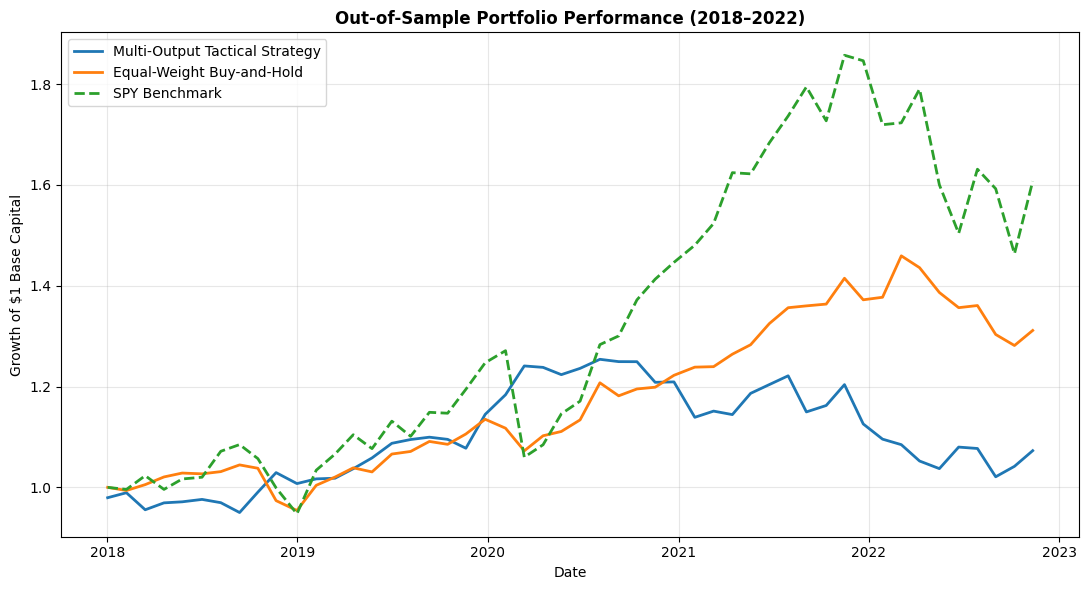

In [ ]:
pred_df = pd.DataFrame(Y_pred_te_multi, index=test_dates, columns=tickers)
realized_df = pd.DataFrame(Y_te_multi, index=test_dates, columns=tickers)

# Non-overlapping 25-day rebalancing origins
rebal_dates = pred_df.index[::25]
strat_returns = []

for dt in rebal_dates:
    pred_ranks = pred_df.loc[dt].sort_values()
    longs = list(pred_ranks.index[-2:])   # Top 2 predicted
    shorts = list(pred_ranks.index[:2])   # Bottom 2 predicted

    w = pd.Series(0.0, index=tickers)
    w.loc[longs] = 0.25
    w.loc[shorts] = -0.25

    ret_25d = float((w * realized_df.loc[dt]).sum())
    strat_returns.append({
        "Date": dt,
        "Strategy Return (%)": ret_25d,
        "Longs": ", ".join(longs),
        "Shorts": ", ".join(shorts)
    })

bt_df = pd.DataFrame(strat_returns).set_index("Date")

# Wealth Accumulation starting from $1.00 base capital
bt_df["Strategy Wealth"] = (1.0 + bt_df["Strategy Return (%)"] / 100.0).cumprod()

# Benchmark 1: Equal-Weight Buy-and-Hold
b_prices = raw_prices.loc[test_start_date:test_end_date, tickers]
b_relatives = b_prices / b_prices.iloc[0]
b_wealth_daily = b_relatives.mean(axis=1)
bt_df["Equal-Weight B&H Wealth"] = b_wealth_daily.reindex(bt_df.index, method='ffill').values
bt_df["Equal-Weight Return (%)"] = bt_df["Equal-Weight B&H Wealth"].pct_change() * 100.0
bt_df.loc[bt_df.index[0], "Equal-Weight Return (%)"] = (bt_df.loc[bt_df.index[0], "Equal-Weight B&H Wealth"] - 1.0) * 100.0

# Benchmark 2: SPY Buy-and-Hold
spy_p = raw_prices.loc[test_start_date:test_end_date, 'SPY']
spy_wealth_daily = spy_p / spy_p.iloc[0]
bt_df["SPY Wealth"] = spy_wealth_daily.reindex(bt_df.index, method='ffill').values
bt_df["SPY Return (%)"] = bt_df["SPY Wealth"].pct_change() * 100.0
bt_df.loc[bt_df.index[0], "SPY Return (%)"] = (bt_df.loc[bt_df.index[0], "SPY Wealth"] - 1.0) * 100.0

# Backtest Performance Summary
periods_per_year = 252 / 25
def calc_stats(ret_pct_series, wealth_series):
    r = ret_pct_series.dropna() / 100.0
    w = wealth_series.dropna()
    total_ret = float(w.iloc[-1] - 1.0)
    ann_ret = float((w.iloc[-1]) ** (periods_per_year / len(r)) - 1.0)
    ann_vol = float(r.std(ddof=1) * np.sqrt(periods_per_year))
    sharpe = float((r.mean() / r.std(ddof=1) * np.sqrt(periods_per_year)) if r.std(ddof=1) > 0 else np.nan)
    max_dd = float((w / w.cummax() - 1.0).min())
    pos_ratio = float((r > 0).mean())
    return {
        "Total Return": total_ret,
        "Annualized Return": ann_ret,
        "Annualized Volatility": ann_vol,
        "Sharpe Ratio (rf=0)": sharpe,
        "Maximum Drawdown": max_dd,
        "Positive Periods": pos_ratio
    }

stats_summary = pd.DataFrame({
    "Multi-Output Strategy": calc_stats(bt_df["Strategy Return (%)"], bt_df["Strategy Wealth"]),
    "Equal-Weight Buy-and-Hold": calc_stats(bt_df["Equal-Weight Return (%)"], bt_df["Equal-Weight B&H Wealth"]),
    "SPY Benchmark": calc_stats(bt_df["SPY Return (%)"], bt_df["SPY Wealth"])
}).T

print("\n--- Step 6: Performance Statistics ---")
display(stats_summary.style.format("{:.4f}"))

# Plot Cumulative Growth
plt.figure(figsize=(11, 6))
plt.plot(bt_df.index, bt_df["Strategy Wealth"], label="Multi-Output Tactical Strategy", linewidth=2)
plt.plot(bt_df.index, bt_df["Equal-Weight B&H Wealth"], label="Equal-Weight Buy-and-Hold", linewidth=2)
plt.plot(bt_df.index, bt_df["SPY Wealth"], label="SPY Benchmark", linewidth=2, linestyle='--')
plt.title("Out-of-Sample Portfolio Performance (2018–2022)", fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Growth of $1 Base Capital")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## **Interpretation of Results:**

* **Tactical Strategy Performance:** Over the out-of-sample period (2018–2022), the multi-output tactical strategy generated a positive cumulative return of **+7.28%** (annualized: **+1.43%**, annualized volatility: **8.94%**, Sharpe ratio: **0.2026**, maximum drawdown: **-18.59%**, positive periods: **56.00%**).

* **Comparison with Benchmarks:** While the strategy achieved a positive absolute return and substantially lower volatility than the broad equity market (8.94% vs. SPY's 16.52%), it trailed both the passive **Equal-Weight Buy-and-Hold benchmark (+31.14%, Sharpe: 0.7307, Max Drawdown: -12.19%)** and the equity market (**SPY: +60.75%, Sharpe: 0.6653**).

* **Dollar Neutrality vs. Equity Drift:** The strategy maintained a dollar-neutral structure (+25% each in the top two predicted ETFs, -25% each in the bottom two). While this reduced net equity market exposure relative to a long-only portfolio, it does not guarantee beta neutrality ($\beta_p = 0$). By holding short positions during the 2019–2021 market appreciation, the tactical strategy forfeited broad market drift.

* **Regime Shifts & Timing Drag:** Across the 2018–2022 window (including the late-2018 tightening, the 2020 market crash, and the 2022 inflation cycle), 25-day rebalancing incurred timing drag during sudden market turning points, explaining the performance gap against passive buy-and-hold allocations.

## Step 7: Synthesis and Academic Discussion

### 1. Comparative Predictability Properties of MLP, CNN-GAF, and LSTM
* **Feedforward Multi-Layer Perceptrons (MLP):** The single-asset MLP maps five engineered multi-horizon momentum lags to future returns. Because it processes lags as independent feature nodes without preserving sequential structure, it underfits time-varying serial dynamics. However, its low parameter count provides baseline stability against noise.

* **CNN with Gramian Angular Fields (CNN-GAF):** Transforming a 30-day temporal series into a $30 \times 30$ GAF image maps continuous paths into a 2D matrix. In this sample, spatial convolution proved most effective for interest-rate-sensitive assets (SHY Test $R^2$: 0.0676; TLT Test $R^2$: 0.0238), which exhibit smoother autocorrelation structures. Conversely, it did not resolve predictive noise in equities (SPY Test $R^2$: -0.0054) or gold (GLD Test $R^2$: -0.0320).

* **Recurrent Gating (LSTM):** Single-output LSTMs process input observations sequentially through internal memory cells ($C_t$) and forget gates ($f_t$). In this sample, explicit 30-day sequence modeling produced positive out-of-sample $R^2$ across four of the five asset classes (SPY, TLT, SHY, DBO), showing that time-domain sequential modeling captures medium-term persistence better than static multi-horizon features.

### 2. Multi-Output vs. Single-Output Predictive Implications
* **Empirical Comparison:** In our experiment, the multi-output multivariate LSTM improved out-of-sample $R^2_{\text{OOS}}$ for every asset relative to the single-output LSTM:
  * **SPY:** +0.0171 (vs. +0.0009 single)
  * **TLT:** +0.0247 (vs. +0.0219 single)
  * **SHY:** +0.0785 (vs. +0.0633 single)
  * **GLD:** +0.0091 (vs. -0.0005 single)
  * **DBO:** +0.0296 (vs. +0.0222 single)

* **Interpretation of Cross-Asset Signals:** The joint architecture grants each ETF forecast access to the representations of all five asset classes. These consistent empirical gains support the premise that multi-asset representations capture cross-market linkages. However, this joint deep learning structure does not isolate specific transmission mechanisms or establish economic causality.

### 3. Tactical Asset Allocation vs. Equal-Weight Buy-and-Hold Benchmark
* **Empirical Reality:** While multi-output deep learning models generated positive out-of-sample predictive $R^2$ at the individual asset level, converting these forecasts into a systematic dollar-neutral tactical strategy (+7.28% return, 0.2026 Sharpe) did not outperform the passive Equal-Weight Buy-and-Hold benchmark (+31.14% return, 0.7307 Sharpe).

* **Methodological Conclusion:** Statistical forecast improvement does not inherently ensure portfolio outperformance. Maintaining a dollar-neutral structure sacrificed market drift, while periodic 25-day rebalancing incurred timing drag during regime transitions. This indicates that predictive gains at the individual asset level do not directly guarantee superior systematic portfolio performance.

---

### Consolidated Empirical Summary Tables

**Table 1: Out-of-Sample Predictive Fit Across Architectures (Test $R^2_{\text{OOS}}$)**

| ETF Ticker | Asset Class | Step 2: MLP | Step 3: CNN-GAF | Step 4: Single LSTM | Step 5: Multi LSTM |
| :--- | :--- | :---: | :---: | :---: | :---: |
| **SPY** | U.S. Equities | -0.0081 | -0.0054 | 0.0009 | **0.0171** |
| **TLT** | 20+ Yr Treasury | 0.0094 | 0.0238 | 0.0219 | **0.0247** |
| **SHY** | 1–3 Yr Treasury | 0.0426 | 0.0676 | 0.0633 | **0.0785** |
| **GLD** | Gold | -0.0219 | -0.0320 | -0.0005 | **0.0091** |
| **DBO** | Crude Oil | 0.0377 | 0.0254 | 0.0222 | **0.0296** |

**Table 2: Out-of-Sample Portfolio Performance Summary (2018–2022)**

| Performance Metric | Multi-Output Tactical Strategy | Equal-Weight Buy-and-Hold | SPY Equity Benchmark |
| :--- | :---: | :---: | :---: |
| **Total Cumulative Return** | **+7.28%** | **+31.14%** | **+60.75%** |
| **Annualized Return (CAGR)** | +1.43% | +5.62% | +10.04% |
| **Annualized Volatility** | 8.94% | 7.92% | 16.52% |
| **Sharpe Ratio ($r_f = 0$)** | 0.2026 | **0.7307** | 0.6653 |
| **Maximum Drawdown** | **-18.59%** | **-12.19%** | -21.21% |
| **Positive Rebalance Periods** | 56.00% | 66.00% | 64.00% |

> **Note on Test Period Horizon:** The target variable represents a 25-trading-day forward holding period. Because raw historical prices terminate on December 30, 2022, `dropna()` automatically excludes the final 25 trading days where future targets are unobservable. The effective out-of-sample forecast origin dates span from January 2018 through late November 2022, preventing look-ahead bias.